In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_csv('D:\pythonML-class\Mall_Customers_Synthetic.csv')
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,56,53,95
1,2,46,16,99
2,3,32,17,60
3,4,60,127,97
4,5,25,115,63


In [7]:
#preprocessing
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X

,Age,Annual Income (k$),Spending Score (1-100)
0,56,53,95
1,46,16,99
2,32,17,60
3,60,127,97
4,25,115,63
...,...,...,...
195,49,38,8
196,49,107,93
197,41,127,26
198,58,60,74


In [10]:
scaler = StandardScaler()
X_scaled =scaler.fit_transform(X)


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

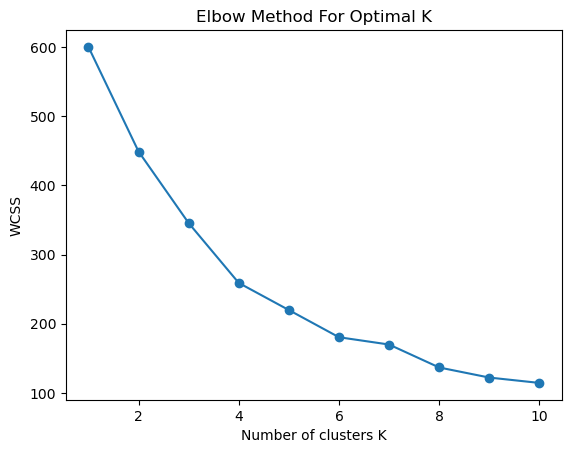

In [12]:
#determining optimal K
wcss = []
K = range(1,11)
for k in K:
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.plot(K, wcss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS')
plt.show()

In [13]:
for k in range(2,8):
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    print(f'For n_clusters = {k}, silhouette score is {sil_score}')

For n_clusters = 2, silhouette score is 0.24310262073693678
For n_clusters = 3, silhouette score is 0.25680320676179497
For n_clusters = 4, silhouette score is 0.2964320357191702
For n_clusters = 5, silhouette score is 0.29612520474307075
For n_clusters = 6, silhouette score is 0.30811332443588785
For n_clusters = 7, silhouette score is 0.28571758470711933


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data['Cluster'] = clusters
print(data.head())

   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   56                  53                      95        3
1   46                  16                      99        3
2   32                  17                      60        1
3   60                 127                      97        0
4   25                 115                      63        1


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


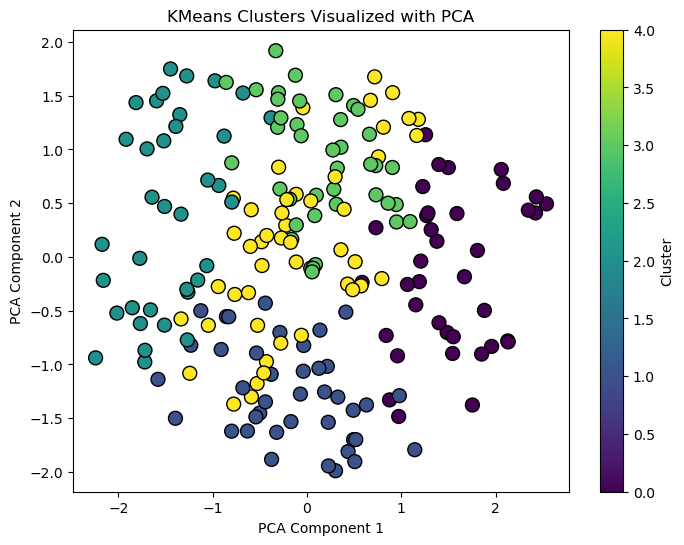

In [16]:
#visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', marker='o', edgecolor='k', s=100)
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()
